In [25]:
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.datasets import fashion_mnist

from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    accuracy_score, 
    f1_score, 
    precision_score, 
    recall_score, 
    precision_score
)

In [26]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [27]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(X_train.min(), X_train.max())

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)
0 255


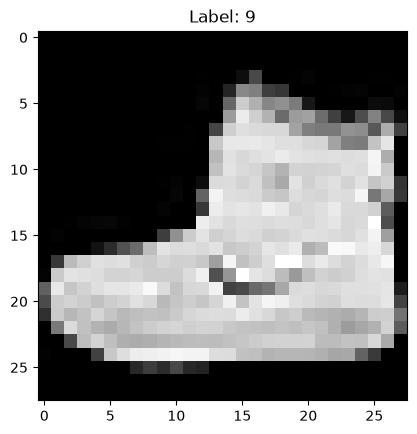

In [28]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.show()

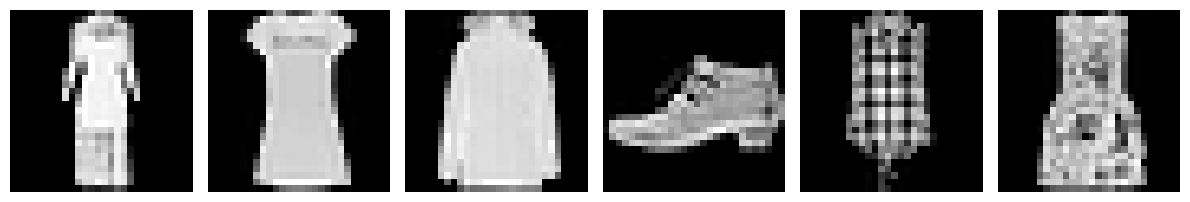

In [29]:
indices = np.random.choice(len(X_train), 6, replace= False)
selected_images = [X_train[i] for i in indices]

fig, axes = plt.subplots(1, 6, figsize=(12, 4))

for ax, img, in zip(axes, selected_images):
    ax.imshow(img, cmap="gray")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [30]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print(class_names[y_train[0]])

Ankle boot


In [31]:
# Data Preprocessing

X_train = X_train.reshape(*X_train.shape, 1)
X_test = X_test.reshape(*X_test.shape, 1)

# min-max scaling
X_train = X_train / 255
X_test = X_test / 255

In [32]:
print(X_train.shape, X_test.shape)
print(X_train.min(), X_train.max())

(60000, 28, 28, 1) (10000, 28, 28, 1)
0.0 1.0


In [33]:
one_hot_encoder = OneHotEncoder(sparse_output=False)
y_train = one_hot_encoder.fit_transform(y_train.reshape(-1, 1))
y_test = one_hot_encoder.transform(y_test.reshape(-1, 1))

In [34]:
print(y_train.shape, y_test.shape)
print(y_train[0])

(60000, 10) (10000, 10)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [35]:
print(one_hot_encoder.categories_[0])

[0 1 2 3 4 5 6 7 8 9]


In [36]:
input_shape = X_train.shape[1:]
input_shape

(28, 28, 1)

In [ ]:
input_layer = Input(shape=input_shape)

model = Sequential([
    input_layer,

    Conv2D(
        filters=32, # number of filters, i use 32 filters for the first convolutional layer
        kernel_size=(3, 3), # size of the convolutional kernel, i use a 3x3 kernel
        activation='relu' # activation function
    ),

    MaxPooling2D(pool_size=(2, 2)), # max pooling layer

    Conv2D(
        filters=64, # number of filters, i use 64 filters for the second convolutional layer
        kernel_size=(3, 3), # size of the convolutional kernel, i use a 3x3 kernel
        activation='relu' # activation function
    ),

    MaxPooling2D(pool_size=(2, 2)), # max pooling layer

    Flatten(), # flatten the output of the previous layer to feed it into the dense layer

    Dense(
        units=128, # number of neurons in the dense layer
        activation='relu' # activation function
    ),

    Dropout(rate=0.5), # dropout layer to prevent overfitting, i use a dropout rate of 0.5

    Dense(
        units=10, # number of neurons in the output layer
        activation='softmax' # activation function for multi-class classification
    )

])

model.compile(
    optimizer='adam', # optimizer for training the model
    loss='categorical_crossentropy', # loss function for multi-class classification
    metrics=['accuracy'] # metrics to evaluate the model's performance
    )

In [38]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10, # number of epochs to train the model
    batch_size=128, # size of the batches of data to feed into the model during training
    validation_split=0.2, # fraction of the training data to be used as validation data
    shuffle=True # shuffle the training data before each epoch to prevent the model from learning the order of the data
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.7496 - loss: 0.6887 - val_accuracy: 0.8436 - val_loss: 0.4242
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8393 - loss: 0.4477 - val_accuracy: 0.8661 - val_loss: 0.3673
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8602 - loss: 0.3909 - val_accuracy: 0.8777 - val_loss: 0.3329
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8725 - loss: 0.3548 - val_accuracy: 0.8884 - val_loss: 0.3036
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8801 - loss: 0.3311 - val_accuracy: 0.8892 - val_loss: 0.3057
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.8886 - loss: 0.3106 - val_accuracy: 0.8954 - val_loss: 0.2868
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8934 - loss: 0.2932 - val_accuracy: 0.8973 - val_loss: 0.2762
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8980 - loss: 0.2802 - val_accu

In [40]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9020 - loss: 0.2690
Test Loss: 0.2690
Test Accuracy: 0.9020


In [41]:
y_pred = np.argmax(model.predict(X_test), axis=1)
print(f"Predicted Labels: {y_pred}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted Labels: [9 2 1 ... 8 1 5]


In [42]:
y_true = np.argmax(y_test, axis=1)
print(f"True Labels: {y_true}")

True Labels: [9 2 1 ... 8 1 5]


In [43]:
confusion_mat = confusion_matrix(y_true, y_pred)
print(f"Confusion Matrix:\n{confusion_mat}")

Confusion Matrix:
[[814   0   9  19   2   1 151   0   4   0]
 [  1 974   1  19   2   0   1   0   2   0]
 [ 13   0 793  14  65   0 114   0   1   0]
 [  7   0   6 931  14   0  42   0   0   0]
 [  0   1  22  42 870   0  65   0   0   0]
 [  0   0   0   0   0 985   0  11   0   4]
 [ 85   0  43  28  73   0 765   0   6   0]
 [  0   0   0   0   0  14   0 976   0  10]
 [  2   0   3   6   3   3   9   3 971   0]
 [  0   0   0   0   0   4   1  54   0 941]]


In [44]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

In [45]:
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.9020
Precision: 0.9062
Recall: 0.9020
F1-Score: 0.9031
